# PPE Safety Checker
Detects missing Personal Protective Equipment (PPE) in construction site images.  
Flags workers without helmets, safety vests, or masks and saves annotated alert images.

**Dataset:** Construction Site Safety — 2,801 images, 10 classes  
**Model:** YOLOv8m fine-tuned for 100 epochs  
**Unsafe classes:** `NO-Hardhat` · `NO-Safety Vest` · `NO-Mask`

## 1 — Setup

In [43]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
import torch

BASE      = Path(".").resolve()
DATA_YAML = BASE / "data.yaml"
TRAIN_IMG = BASE / "data" / "train" / "images"
TEST_IMG  = BASE / "data" / "test"  / "images"
SAMPLES   = BASE / "samples"
FLAGGED   = BASE / "flagged"
FLAGGED.mkdir(exist_ok=True)

UNSAFE_CLASSES = {"NO-Hardhat", "NO-Safety Vest", "NO-Mask"}

print(f"PyTorch  : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"Train    : {len(list(TRAIN_IMG.glob('*.jpg')))} images")
print(f"Test     : {len(list(TEST_IMG.glob('*.jpg')))} images")

PyTorch  : 2.11.0+cu128
GPU      : NVIDIA GeForce RTX 5070 Ti
Train    : 2605 images
Test     : 82 images


## 2 — Dataset Overview

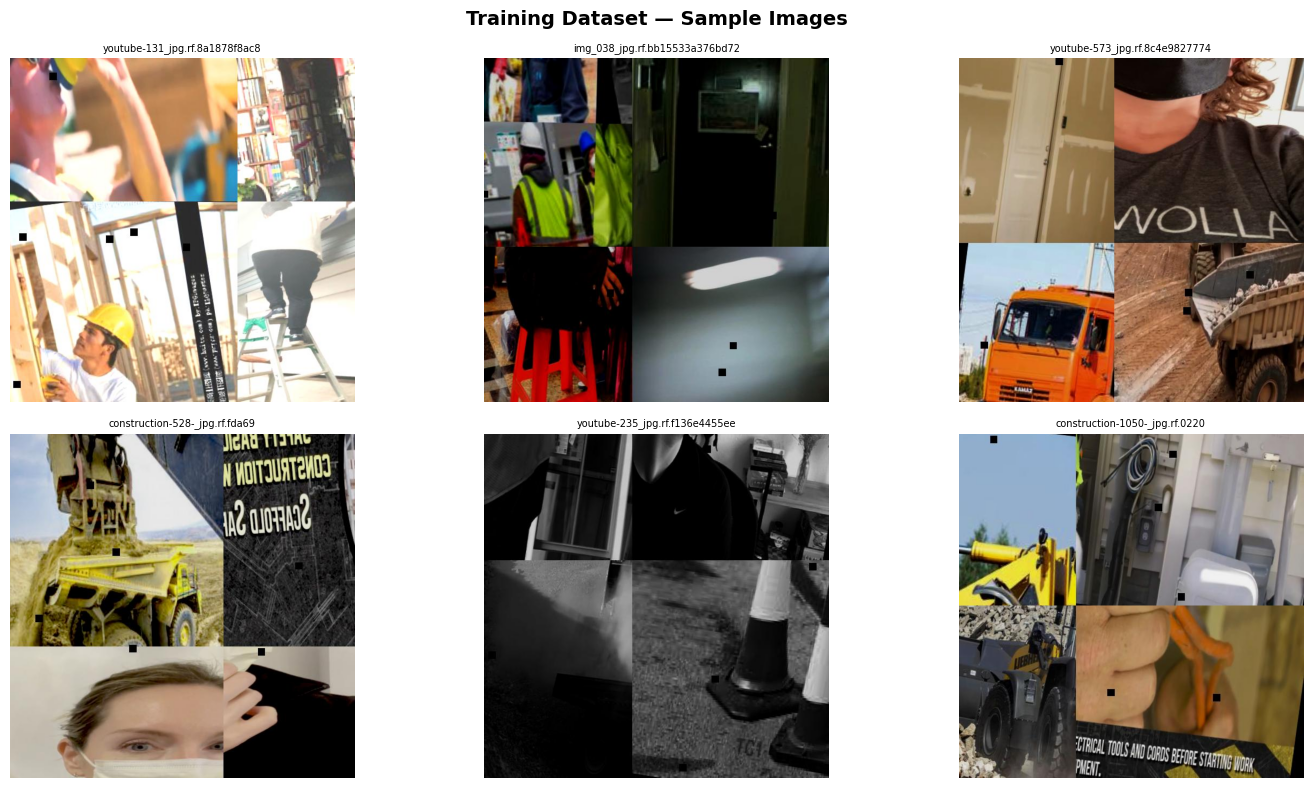

In [44]:
samples = random.sample(list(TRAIN_IMG.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Training Dataset — Sample Images", fontsize=14, fontweight="bold")

for ax, img_path in zip(axes.flatten(), samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name[:30], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3 — Model Training
Fine-tuning YOLOv8m on the construction safety dataset.  
The medium variant carries roughly 25M parameters — more capacity than the small variant — which raises recall on partially occluded and background workers, the cases a safety system must not miss.  
YOLO11m was also evaluated (see the Model Comparison below); YOLOv8m was retained for its higher recall, the priority metric for a safety system.  
Training runs on GPU and takes approximately 60–90 minutes.

In [ ]:
model = YOLO("yolov8m.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    name="ppe_model_m",
    project="runs",
    patience=15,
    device=0,
    verbose=True,
)

BEST_MODEL = BASE / "runs" / "detect" / "runs" / "ppe_model_m" / "weights" / "best.pt"
print(f"\nBest model saved to: {BEST_MODEL}")

### Training Results

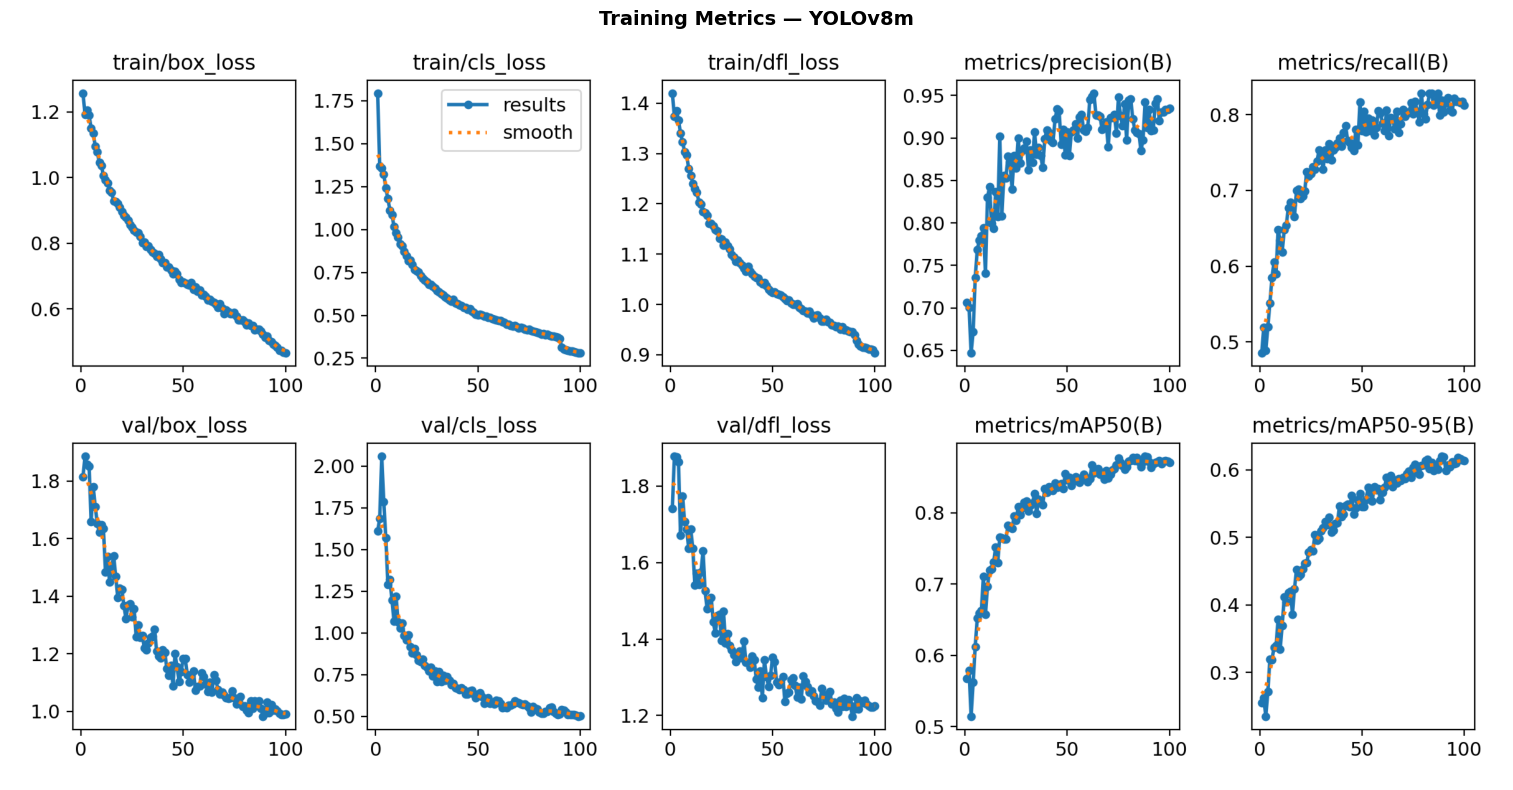

In [46]:
results_img = BASE / "runs" / "detect" / "runs" / "ppe_model_m" / "results.png"

img = cv2.imread(str(results_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Training Metrics — YOLOv8m", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Model Comparison
Reads the metrics of every trained model from its `results.csv` and ranks them.  
Each row reports the best-fitness epoch — the same checkpoint saved as `best.pt`.

In [45]:
import pandas as pd

RUNS_DIR = BASE / "runs" / "detect" / "runs"

rows = []
if RUNS_DIR.exists():
    for run in sorted(RUNS_DIR.iterdir()):
        csv = run / "results.csv"
        if not csv.exists():
            continue
        df = pd.read_csv(csv)
        df.columns = df.columns.str.strip()
        fitness = 0.1 * df["metrics/mAP50(B)"] + 0.9 * df["metrics/mAP50-95(B)"]
        best = df.loc[fitness.idxmax()]
        rows.append({
            "model"     : run.name,
            "precision" : round(best["metrics/precision(B)"], 3),
            "recall"    : round(best["metrics/recall(B)"], 3),
            "mAP50"     : round(best["metrics/mAP50(B)"], 3),
            "mAP50-95"  : round(best["metrics/mAP50-95(B)"], 3),
            "best_epoch": int(best["epoch"]) + 1,
        })

if rows:
    comparison = pd.DataFrame(rows).sort_values("mAP50-95", ascending=False).reset_index(drop=True)
    print(comparison.to_string(index=False))
else:
    print("No training runs found in runs/.")
    print("Training output is not version-controlled. Train a model to populate this table,")
    print("or see the saved comparison in the committed notebook outputs.")

       model  precision  recall  mAP50  mAP50-95  best_epoch
     ppe_11m      0.952   0.798  0.868     0.625          90
 ppe_model_m      0.912   0.819  0.878     0.620          90
ppe_model_v2      0.915   0.795  0.854     0.575          89
   ppe_model      0.878   0.695  0.786     0.480          51


## 4 — Safety Checker
Runs the trained model on input images. Any image where an unsafe class is detected triggers an alert, gets annotated with bounding boxes, and is saved to the `flagged/` folder.

In [47]:
BEST_MODEL = BASE / "runs" / "detect" / "runs" / "ppe_model_m" / "weights" / "best.pt"
checker    = YOLO(str(BEST_MODEL))

ALERT_COLOR    = (0, 0, 255)
SAFE_COLOR     = (0, 200, 0)
CONF_THRESHOLD = 0.35

def run_safety_check(image_path: Path) -> dict:
    img    = cv2.imread(str(image_path))
    result = checker(str(image_path), conf=CONF_THRESHOLD, verbose=False)[0]
    names  = result.names

    detected = [names[int(c)] for c in result.boxes.cls] if result.boxes else []
    alerts   = [d for d in detected if d in UNSAFE_CLASSES]
    is_safe  = len(alerts) == 0

    for box, cls in zip(result.boxes.xyxy, result.boxes.cls):
        label  = names[int(cls)]
        color  = ALERT_COLOR if label in UNSAFE_CLASSES else SAFE_COLOR
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    status_text  = "SAFE" if is_safe else f"ALERT: {', '.join(set(alerts))}"
    status_color = SAFE_COLOR if is_safe else ALERT_COLOR
    cv2.putText(img, status_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, status_color, 2)

    if not is_safe:
        out_path = FLAGGED / f"flagged_{image_path.name}"
        cv2.imwrite(str(out_path), img)

    return {
        "file"     : image_path.name,
        "detected" : detected,
        "alerts"   : list(set(alerts)),
        "safe"     : is_safe,
        "annotated": img,
    }

### Run on Test Images

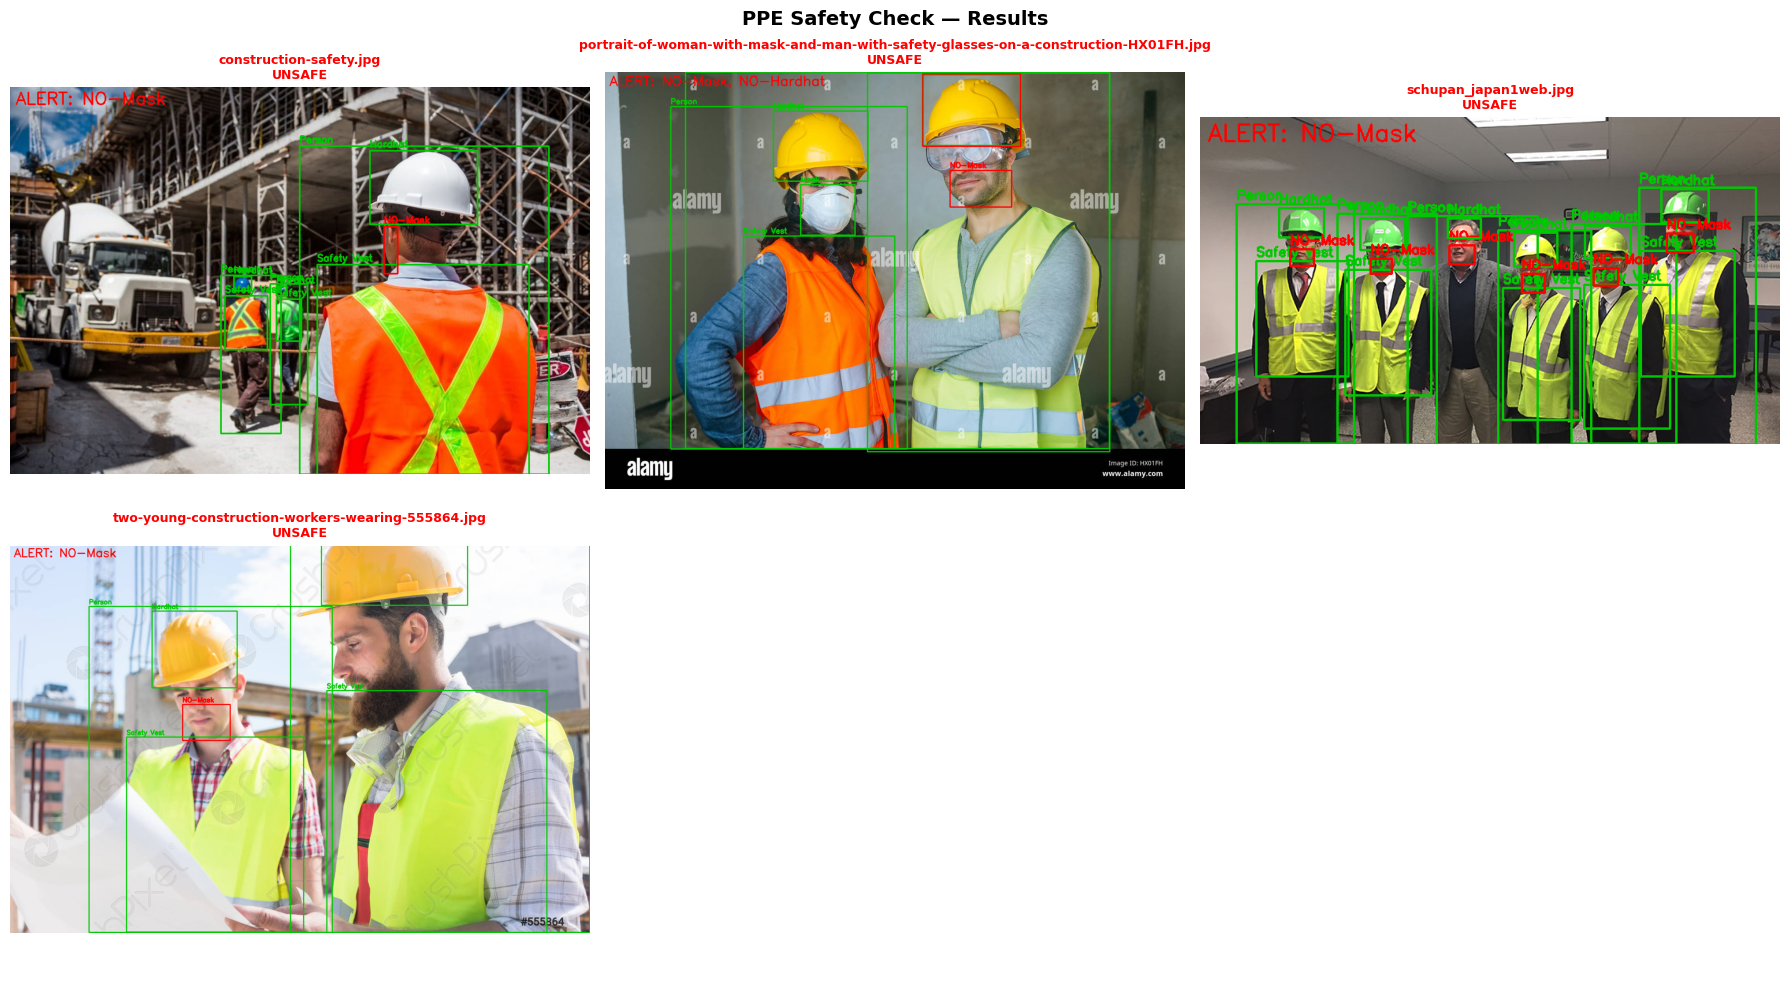

In [48]:
test_images = list(SAMPLES.glob("*.jpg"))
reports     = [run_safety_check(img) for img in test_images]

cols = min(3, len(reports))
rows = (len(reports) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = [axes] if len(reports) == 1 else axes.flatten()

for ax, report in zip(axes, reports):
    rgb = cv2.cvtColor(report["annotated"], cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    title_color = "red" if not report["safe"] else "green"
    status = "UNSAFE" if not report["safe"] else "SAFE"
    ax.set_title(f"{report['file']}\n{status}", color=title_color, fontsize=9, fontweight="bold")
    ax.axis("off")

for ax in axes[len(reports):]:
    ax.axis("off")

plt.suptitle("PPE Safety Check — Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5 — Summary

In [49]:
total    = len(reports)
unsafe   = [r for r in reports if not r["safe"]]
safe     = [r for r in reports if r["safe"]]
flagged  = list(FLAGGED.glob("*.jpg"))

print("=" * 45)
print("         PPE SAFETY CHECK — SUMMARY")
print("=" * 45)
print(f"  Images processed : {total}")
print(f"  Safe             : {len(safe)}")
print(f"  Unsafe (alerts)  : {len(unsafe)}")
print(f"  Flagged images   : {len(flagged)} saved to flagged/")
print("-" * 45)

for r in unsafe:
    violations = ", ".join(r["alerts"])
    print(f"  ⚠  {r['file']}")
    print(f"     Violations: {violations}")

print("=" * 45)

         PPE SAFETY CHECK — SUMMARY
  Images processed : 4
  Safe             : 0
  Unsafe (alerts)  : 4
  Flagged images   : 4 saved to flagged/
---------------------------------------------
  ⚠  construction-safety.jpg
     Violations: NO-Mask
  ⚠  portrait-of-woman-with-mask-and-man-with-safety-glasses-on-a-construction-HX01FH.jpg
     Violations: NO-Mask, NO-Hardhat
  ⚠  schupan_japan1web.jpg
     Violations: NO-Mask
  ⚠  two-young-construction-workers-wearing-555864.jpg
     Violations: NO-Mask
